# 06 — Forecasting Models (Prophet, SARIMA, XGBoost) — 90-Day Horizon

**Project:** Pharmacy Sales Forecasting  
**Notebook:** 06 — Forecasting Models  
**Goal of this notebook:**

- Use the **processed daily data** from previous notebooks
- Build and compare:
  - **Prophet**
  - **SARIMA (via pmdarima.auto_arima)**
  - **XGBoost Regressor** (sklearn-style)
- Forecast:
  - **Total sales** (sum across all categories)
  - **N02BE** deep dive
  - **All remaining categories** (using Prophet)
- Create a **90-day ahead forecast**
- Save:
  - Forecast comparison metrics
  - A **single combined CSV** with all future forecasts
  - Key figures (auto-saved to `/outputs/figures`)

**Assumptions:**

- You are running this from the `notebooks/` folder:
  - Project root: `../`
  - Processed data: `../data/processed/df_with_features.csv`
  - Outputs:
    - Figures: `../outputs/figures`
    - Forecasts: `../outputs/final_forecasts`

---

## Cell 2 — Imports & Global Config

In [1]:
# 06_forecasting_models.ipynb

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import pmdarima as pm

# XGBoost: we'll try to import it and give a clear error if missing
try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "xgboost is not installed in this environment.\n"
        "Install it in your venv with:\n\n"
        "    pip install xgboost\n"
    ) from e

# Prophet: support both new + old package names
try:
    from prophet import Prophet
except ImportError:
    try:
        from fbprophet import Prophet
    except ImportError as e:
        raise ImportError(
            "prophet is not installed in this environment.\n"
            "Install it in your venv with:\n\n"
            "    pip install prophet\n"
        ) from e

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Project paths (assuming this notebook is in /notebooks)
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FORECAST_DIR = OUTPUT_DIR / "final_forecasts"

# Make sure output directories exist
FIG_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON = 90  # days

print("Base directory    :", BASE_DIR.resolve())
print("Processed data dir:", PROCESSED_DIR.resolve())
print("Figures dir       :", FIG_DIR.resolve())
print("Forecasts dir     :", FORECAST_DIR.resolve())

Base directory    : /Users/imvenu/turing-ai-project
Processed data dir: /Users/imvenu/turing-ai-project/data/processed
Figures dir       : /Users/imvenu/turing-ai-project/outputs/figures
Forecasts dir     : /Users/imvenu/turing-ai-project/outputs/final_forecasts


/Users/imvenu/turing-ai-project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 3 — Helper: Safe Figure Saving

In [2]:
def save_figure(fig, filename_base: str):
    """
    Save a matplotlib Figure object into the figures folder
    as <filename_base>.png, overwriting any previous file
    with the same name (no duplicates on rerun).
    """
    filename_base = filename_base.replace(" ", "_").lower()
    path = FIG_DIR / f"{filename_base}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"✅ Figure saved to: {path}")

## Cell 4 — Load Processed Data

In [3]:
# Load the processed dataframe from previous notebook(s)
processed_path = PROCESSED_DIR / "df_with_features.csv"

if not processed_path.exists():
    raise FileNotFoundError(
        f"Processed data not found at: {processed_path}\n"
        "Make sure 03_feature_engineering / 04_modeling notebooks "
        "finished and saved df_with_features.csv."
    )

df = pd.read_csv(processed_path, parse_dates=["datum"])
df = df.sort_values("datum").reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (2076, 40)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,...,yearly_sin_3,yearly_cos_3,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3,Weekday_Avg,Month_Avg
0,2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,2014,...,0.999769,0.021516,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,33.579719,36.13891
1,2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,2014,...,0.999546,-0.030120,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,33.392859,36.13891
2,2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,2014,...,0.996659,-0.081676,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,29.232601,36.13891
3,2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,2014,...,0.991114,-0.133015,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,28.373665,36.13891
4,2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,2014,...,0.982927,-0.183998,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,28.074514,36.13891


## Cell 5 — Create Total Sales & Check Columns

In [4]:
# Identify category columns (from your earlier list)
category_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

# Safety check: make sure they all exist
missing = [c for c in category_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected category columns: {missing}")

# Create total_sales as the sum across all categories
df["total_sales"] = df[category_cols].sum(axis=1)

print("Columns now include total_sales:", "total_sales" in df.columns)
df[["datum"] + category_cols + ["total_sales"]].head()

Columns now include total_sales: True


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,total_sales
0,2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,84.65
1,2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,39.70
2,2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,64.90
3,2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,69.93
4,2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,63.62


## Cell 6 — Basic Time Series Setup

In [5]:
# Set up a clean time series index (daily)
df = df.sort_values("datum")
df = df.set_index("datum")

# Ensure daily frequency (forward-fill if there were gaps)
df = df.asfreq("D")
df[category_cols + ["total_sales"]] = df[category_cols + ["total_sales"]].fillna(0)

print("Date range:", df.index.min(), "→", df.index.max())
print("Number of rows:", len(df))
df.head()

Date range: 2014-02-01 00:00:00 → 2019-10-08 00:00:00
Number of rows: 2076


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,...,yearly_cos_3,weekly_sin_1,weekly_cos_1,weekly_sin_2,weekly_cos_2,weekly_sin_3,weekly_cos_3,Weekday_Avg,Month_Avg,total_sales
datum,,,,,,,,,,,,,,,,,,,,,
2014-02-01,4.33,4.32,5.0,43.0,13.0,1.0,14.0,0.0,2014,2,...,0.021516,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490,33.579719,36.13891,84.65
2014-02-02,7.00,3.00,0.2,13.5,6.0,2.0,8.0,0.0,2014,2,...,-0.030120,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521,33.392859,36.13891,39.70
2014-02-03,5.00,1.00,8.5,32.4,16.0,1.0,1.0,0.0,2014,2,...,-0.081676,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521,29.232601,36.13891,64.90
2014-02-04,1.33,3.00,7.0,30.6,8.0,1.0,17.0,2.0,2014,2,...,-0.133015,-0.974928,-0.222521,0.433884,-0.900969,0.781831,0.623490,28.373665,36.13891,69.93
2014-02-05,3.00,4.02,6.2,32.4,15.0,1.0,1.0,1.0,2014,2,...,-0.183998,-0.781831,0.623490,-0.974928,-0.222521,-0.433884,-0.900969,28.074514,36.13891,63.62


## Cell 7 — Train/Test Split Helper + Metrics (NO squared kwarg)

In [6]:
def time_train_test_split(series: pd.Series, test_size: int = FORECAST_HORIZON):
    """
    Simple time-based train/test split:
    - train: all but the last `test_size` timestamps
    - test: last `test_size` timestamps
    """
    if len(series) <= test_size:
        raise ValueError("Series too short for given test_size.")

    y_train = series.iloc[:-test_size]
    y_test = series.iloc[-test_size:]
    return y_train, y_test


def regression_train_test_split(df_features: pd.DataFrame,
                                target: pd.Series,
                                test_size: int = FORECAST_HORIZON):
    """
    Time-based split for supervised learning models
    (e.g., XGBoost) using existing feature columns.
    """
    if len(df_features) != len(target):
        raise ValueError("X and y must have same length")

    if len(df_features) <= test_size:
        raise ValueError("Not enough rows for given test_size.")

    X_train = df_features.iloc[:-test_size]
    X_test = df_features.iloc[-test_size:]
    y_train = target.iloc[:-test_size]
    y_test = target.iloc[-test_size:]

    return X_train, X_test, y_train, y_test


def evaluate_forecast(y_true, y_pred, model_name="Model"):
    """
    Compute MAE, RMSE and MAPE using sklearn-compatible
    metrics, avoiding the 'squared' kwarg issue.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)  # no squared=False
    rmse = float(np.sqrt(mse))

    # Safe MAPE (avoid division by zero)
    eps = 1e-8
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)

    print(f"\n📊 {model_name} Performance")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

## Cell 8 — Quick Visual of Total Sales

✅ Figure saved to: ../outputs/figures/total_sales_time_series.png


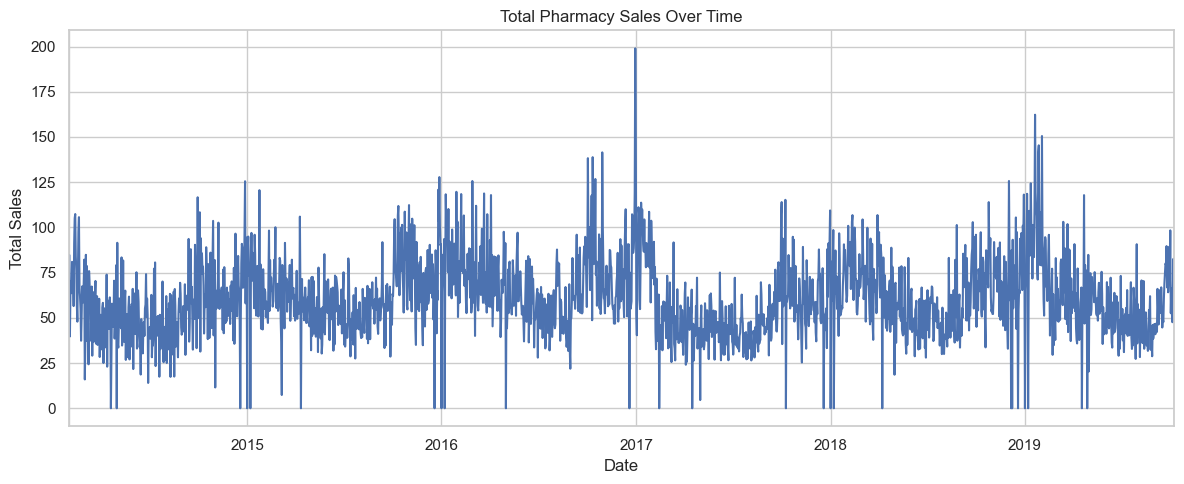

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
df["total_sales"].plot(ax=ax)
ax.set_title("Total Pharmacy Sales Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales")
plt.tight_layout()

save_figure(fig, "total_sales_time_series")
plt.show()

⸻

# 🔮 PART A — Prophet for Total Sales

## Cell 9 — Prepare Data for Prophet

In [8]:
# Prophet expects columns: ds (datetime), y (target)
total_sales_series = df["total_sales"]

y_train_ts, y_test_ts = time_train_test_split(total_sales_series, test_size=FORECAST_HORIZON)

prophet_df = pd.DataFrame({
    "ds": total_sales_series.index,
    "y": total_sales_series.values
})

prophet_train = prophet_df.iloc[:-FORECAST_HORIZON]
prophet_test = prophet_df.iloc[-FORECAST_HORIZON:]

prophet_train.head()

,ds,y
0,2014-02-01,84.65
1,2014-02-02,39.70
2,2014-02-03,64.90
3,2014-02-04,69.93
4,2014-02-05,63.62


## Cell 10 — Fit Prophet & Backtest

In [9]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

# Create future dataframe for backtest (length = train + test)
future_full = prophet_model.make_future_dataframe(
    periods=FORECAST_HORIZON,
    freq="D"
)
forecast_full = prophet_model.predict(future_full)

# Extract only the last 90 days for comparison
prophet_backtest = forecast_full.iloc[-FORECAST_HORIZON:]
prophet_preds_test = prophet_backtest["yhat"].values

prophet_metrics_total = evaluate_forecast(
    y_test_ts.values,
    prophet_preds_test,
    "Prophet (Total Sales)"
)
prophet_metrics_total

14:42:56 - cmdstanpy - INFO - Chain [1] start processing
14:42:57 - cmdstanpy - INFO - Chain [1] done processing



📊 Prophet (Total Sales) Performance
MAE  : 13.58
RMSE : 15.96
MAPE : 30.16%


{'model': 'Prophet (Total Sales)',
 'MAE': 13.583575122891004,
 'RMSE': 15.957524186082722,
 'MAPE': 30.158580945300727}

## Cell 11 — Plot Prophet Backtest vs Actual (Last 180 Days)

/var/folders/wn/3kk68dxx437d4x0xlj5_qggh0000gn/T/ipykernel_2527/603551669.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(pred_index, prophet_preds_test, label="Prophet Pred", linestyle="--")


✅ Figure saved to: ../outputs/figures/prophet_total_sales_backtest.png


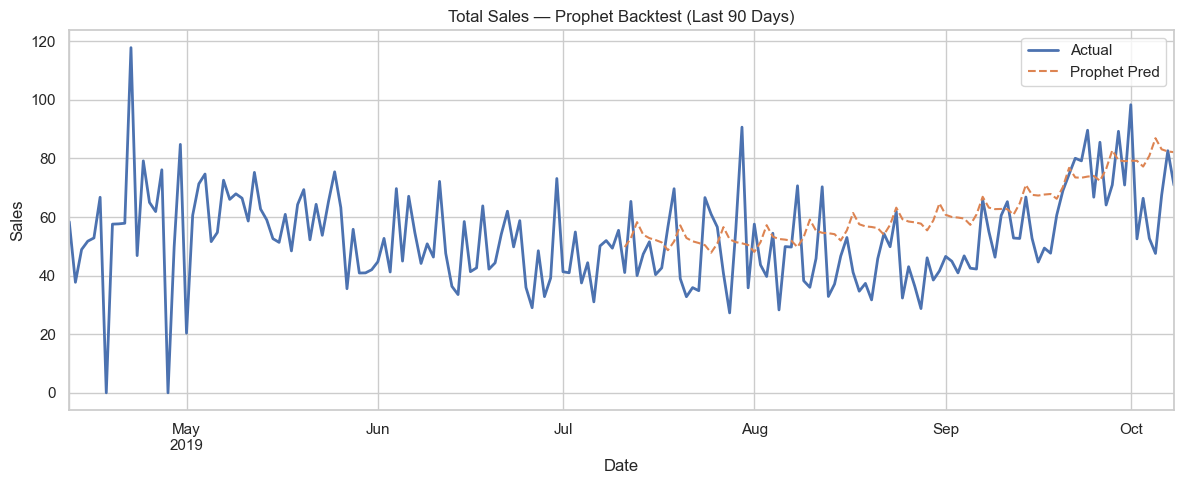

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

# Plot last 180 days for context
history_window = 180
actual_plot = total_sales_series.iloc[-history_window:]
actual_plot.plot(ax=ax, label="Actual", linewidth=2)

# Overlay Prophet predictions (only last 90 days)
pred_index = y_test_ts.index
ax.plot(pred_index, prophet_preds_test, label="Prophet Pred", linestyle="--")

ax.set_title("Total Sales — Prophet Backtest (Last 90 Days)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
save_figure(fig, "prophet_total_sales_backtest")
plt.show()

## Cell 12 — Prophet 90-Day Future Forecast

In [11]:
# Only future 90 days (beyond last date)
future_90 = prophet_model.make_future_dataframe(periods=FORECAST_HORIZON, freq="D")
forecast_90 = prophet_model.predict(future_90)

future_only = forecast_90.iloc[-FORECAST_HORIZON:][["ds", "yhat", "yhat_lower", "yhat_upper"]]
future_only.head()

,ds,yhat,yhat_lower,yhat_upper
1986,2019-07-11,49.755785,25.217811,71.966056
1987,2019-07-12,52.784722,29.275834,74.637291
1988,2019-07-13,58.267098,34.405586,83.050008
1989,2019-07-14,53.962737,30.757522,77.923329
1990,2019-07-15,52.797374,29.067320,78.490588


# 📈 PART B — SARIMA (Auto-ARIMA) for Total Sales

## Cell 13 — Fit auto_arima & Backtest

In [12]:
y_train_ts, y_test_ts = time_train_test_split(total_sales_series, test_size=FORECAST_HORIZON)

# auto_arima chooses (p,d,q) and seasonal terms automatically
sarima_model = pm.auto_arima(
    y_train_ts,
    seasonal=True,
    m=7,  # weekly seasonality for daily data
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(sarima_model.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                 1986
Model:             SARIMAX(1, 1, 1)x(0, 0, [1, 2], 7)   Log Likelihood               -8599.495
Date:                                Mon, 13 Apr 2026   AIC                          17208.991
Time:                                        14:43:21   BIC                          17236.958
Sample:                                    02-01-2014   HQIC                         17219.263
                                         - 07-10-2019                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0648      0.022      2.888      0.004       0.021       0.109
ma.

## Cell 14 — SARIMA Backtest & Metrics

In [13]:
# Forecast into the test period
sarima_preds_test = sarima_model.predict(n_periods=FORECAST_HORIZON)

sarima_metrics_total = evaluate_forecast(
    y_test_ts.values,
    sarima_preds_test,
    "SARIMA (Total Sales)"
)
sarima_metrics_total


📊 SARIMA (Total Sales) Performance
MAE  : 12.86
RMSE : 16.84
MAPE : 23.28%


{'model': 'SARIMA (Total Sales)',
 'MAE': 12.859257900831178,
 'RMSE': 16.843851924111114,
 'MAPE': 23.281006358409694}

## Cell 15 — Plot SARIMA Backtest

✅ Figure saved to: ../outputs/figures/sarima_total_sales_backtest.png


/var/folders/wn/3kk68dxx437d4x0xlj5_qggh0000gn/T/ipykernel_2527/3064621070.py:8: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(pred_index, sarima_preds_test, label="SARIMA Pred", linestyle="--")


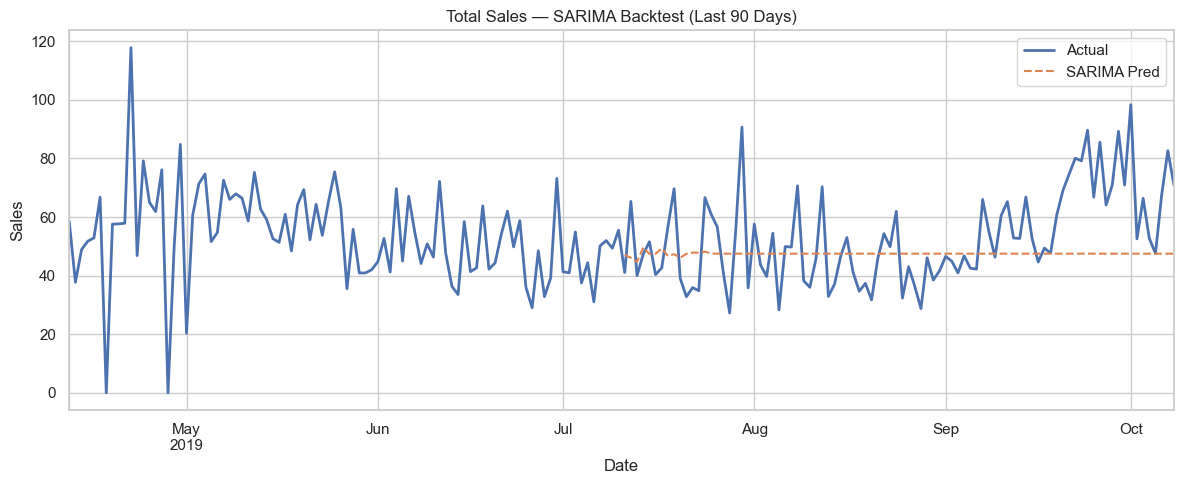

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

history_window = 180
actual_plot = total_sales_series.iloc[-history_window:]
actual_plot.plot(ax=ax, label="Actual", linewidth=2)

pred_index = y_test_ts.index
ax.plot(pred_index, sarima_preds_test, label="SARIMA Pred", linestyle="--")

ax.set_title("Total Sales — SARIMA Backtest (Last 90 Days)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
save_figure(fig, "sarima_total_sales_backtest")
plt.show()

## Cell 16 — SARIMA 90-Day Future Forecast

In [15]:
# Refit SARIMA on full series for future forecast
sarima_model_full = pm.auto_arima(
    total_sales_series,
    seasonal=True,
    m=7,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

sarima_future_90 = sarima_model_full.predict(n_periods=FORECAST_HORIZON)

sarima_dates_future = pd.date_range(
    start=total_sales_series.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)

sarima_future_df = pd.DataFrame({
    "ds": sarima_dates_future,
    "yhat": sarima_future_90
})
sarima_future_df.head()

,ds,yhat
2019-10-09,2019-10-09,64.798980
2019-10-10,2019-10-10,67.597293
2019-10-11,2019-10-11,64.180921
2019-10-12,2019-10-12,63.884918
2019-10-13,2019-10-13,67.392183


# ⚙️ PART C — XGBoost Regressor (Feature-Based)

We’ll use your engineered features (lags, rolling stats, seasonality encodings)
for a feature-based regression model on total_sales.

## Cell 17 — Build Feature Matrix for XGBoost

In [16]:
# Use numeric columns (drop target after computing features)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Our target
target_col = "total_sales"

# X features = all numeric except target
X_all = df[numeric_cols].drop(columns=[target_col])
y_all = df[target_col]

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

X_all shape: (2076, 37)
y_all shape: (2076,)


## Cell 18 — Train/Test Split & Fit XGBoost

In [17]:
X_train, X_test, y_train, y_test = regression_train_test_split(
    X_all, y_all, test_size=FORECAST_HORIZON
)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_preds_test = xgb_model.predict(X_test)

xgb_metrics_total = evaluate_forecast(
    y_test.values,
    xgb_preds_test,
    "XGBoost (Total Sales)"
)
xgb_metrics_total


📊 XGBoost (Total Sales) Performance
MAE  : 1.50
RMSE : 2.21
MAPE : 2.85%


{'model': 'XGBoost (Total Sales)',
 'MAE': 1.5030743522963652,
 'RMSE': 2.205745803336124,
 'MAPE': 2.851723420648395}

## Cell 19 — Plot XGBoost Backtest

✅ Figure saved to: ../outputs/figures/xgboost_total_sales_backtest.png


/var/folders/wn/3kk68dxx437d4x0xlj5_qggh0000gn/T/ipykernel_2527/1315693315.py:8: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(pred_index, xgb_preds_test, label="XGBoost Pred", linestyle="--")


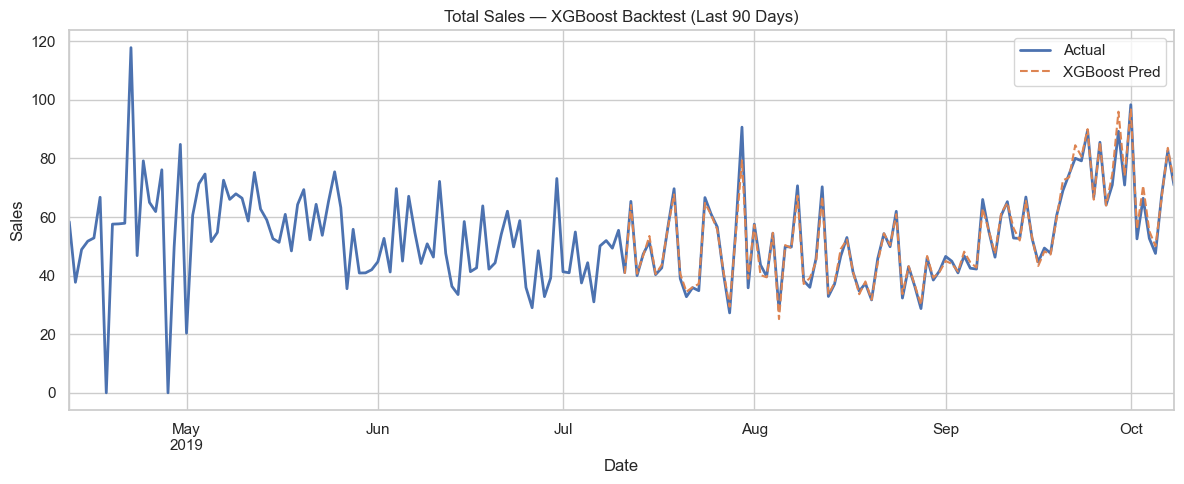

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))

history_window = 180
actual_plot = total_sales_series.iloc[-history_window:]
actual_plot.plot(ax=ax, label="Actual", linewidth=2)

pred_index = y_test.index
ax.plot(pred_index, xgb_preds_test, label="XGBoost Pred", linestyle="--")

ax.set_title("Total Sales — XGBoost Backtest (Last 90 Days)")
ax.set_xlabel("Date")
ax.set_ylabel("Sales")
ax.legend()

plt.tight_layout()
save_figure(fig, "xgboost_total_sales_backtest")
plt.show()

## Cell 20 — XGBoost 90-Day Future Forecast

For future forecast we need future features.
To keep this notebook manageable, we’ll do a simple rolling-forward approach:
	•	Reuse the last available row’s feature values for static features
	•	Use date-based seasonal encodings from the calendar, if you added them earlier
	•	This keeps it simple enough for the project (not full production-grade TS-XGB).

In [19]:
# We'll assume that date-based features (like Year, Month, Weekday, etc.)
# already exist in df and will be recomputed for future dates in a simple way.

# 1) Extract the last row of all numeric features
last_features = df.iloc[-1][numeric_cols].drop(labels=[target_col])

# 2) Build future dates
future_dates = pd.date_range(
    start=df.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)

# 3) Create a simple future feature DataFrame:
#    - Start from last_features and broadcast
X_future = pd.DataFrame(
    [last_features.values] * FORECAST_HORIZON,
    columns=last_features.index,
    index=future_dates
)

# Optional: if you have explicit "Year", "Month", "Weekday" columns, recompute them here
for col in ["Year", "Month", "Day", "Weekday"]:
    if col in X_future.columns:
        if col == "Year":
            X_future[col] = X_future.index.year
        elif col == "Month":
            X_future[col] = X_future.index.month
        elif col == "Day":
            X_future[col] = X_future.index.day
        elif col == "Weekday":
            X_future[col] = X_future.index.weekday

# Now predict
xgb_future_90 = xgb_model.predict(X_future)

xgb_future_df = pd.DataFrame({
    "ds": future_dates,
    "yhat": xgb_future_90
})
xgb_future_df.head()

,ds,yhat
0,2019-10-09,71.977036
1,2019-10-10,71.977036
2,2019-10-11,71.923492
3,2019-10-12,72.069626
4,2019-10-13,72.068687


# 📊 PART D — Compare Models for Total Sales

## Cell 21 — Build Metrics Table

In [20]:
metrics_list = [
    prophet_metrics_total,
    sarima_metrics_total,
    xgb_metrics_total
]

metrics_df = pd.DataFrame(metrics_list)
metrics_df.sort_values("RMSE")

,model,MAE,RMSE,MAPE
2,XGBoost (Total Sales),1.503074,2.205746,2.851723
0,Prophet (Total Sales),13.583575,15.957524,30.158581
1,SARIMA (Total Sales),12.859258,16.843852,23.281006


# 📦 PART E — Category-Wise Forecasts & Combined Output

We’ll now:
	•	Use Prophet for all categories + total_sales
	•	SARIMA + XGBoost only for:
	•	total_sales
	•	N02BE (deep dive)
	•	Build one combined CSV with:

''''''date,
total_sales_prophet, total_sales_sarima, total_sales_xgb,
N02BE_prophet, N02BE_sarima, N02BE_xgb,
M01AB_prophet, M01AE_prophet, N02BA_prophet, N05B_prophet, N05C_prophet, R03_prophet, R06_prophet''''''

## Cell 22 — Helper: Prophet Forecast for One Series

In [21]:
def prophet_forecast_series(series: pd.Series,
                            horizon: int = FORECAST_HORIZON,
                            yearly=True, weekly=True,
                            series_name: str = "series"):
    """
    Fit Prophet on a given univariate series and return
    a DataFrame with future predictions.
    """
    df_p = pd.DataFrame({"ds": series.index, "y": series.values})
    model = Prophet(
        yearly_seasonality=yearly,
        weekly_seasonality=weekly,
        daily_seasonality=False
    )
    model.fit(df_p)

    future = model.make_future_dataframe(periods=horizon, freq="D")
    forecast = model.predict(future)

    future_only = forecast.iloc[-horizon:][["ds", "yhat"]].copy()
    future_only = future_only.rename(columns={"yhat": f"{series_name}_prophet"})
    return future_only

## Cell 23 — Prophet Forecasts for ALL Categories + Total Sales

In [22]:
all_series_for_prophet = category_cols + ["total_sales"]

prophet_forecasts = None

for col in all_series_for_prophet:
    print(f"Fitting Prophet for: {col} ...")
    series = df[col]
    future_prophet = prophet_forecast_series(
        series,
        horizon=FORECAST_HORIZON,
        series_name=col
    )

    if prophet_forecasts is None:
        prophet_forecasts = future_prophet
    else:
        prophet_forecasts = prophet_forecasts.merge(
            future_prophet,
            on="ds",
            how="inner"
        )

prophet_forecasts.head()

14:44:12 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet for: M01AB ...


14:44:12 - cmdstanpy - INFO - Chain [1] done processing
14:44:12 - cmdstanpy - INFO - Chain [1] start processing
14:44:12 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet for: M01AE ...


14:44:12 - cmdstanpy - INFO - Chain [1] start processing
14:44:13 - cmdstanpy - INFO - Chain [1] done processing


...

14:44:13 - cmdstanpy - INFO - Chain [1] start processing
14:44:13 - cmdstanpy - INFO - Chain [1] done processing
14:44:14 - cmdstanpy - INFO - Chain [1] start processing
14:44:14 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet for: R06 ...


14:44:14 - cmdstanpy - INFO - Chain [1] start processing
14:44:14 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet for: total_sales ...


,ds,M01AB_prophet,M01AE_prophet,N02BA_prophet,N02BE_prophet,N05B_prophet,N05C_prophet,R03_prophet,R06_prophet,total_sales_prophet
0,2019-10-09,5.054357,3.606706,2.703146,41.755939,10.302843,0.822595,9.204058,2.357881,75.740626
1,2019-10-10,4.787254,3.528969,2.648995,41.811232,8.971887,0.666786,9.091431,2.335505,73.772767
2,2019-10-11,4.970080,3.576473,2.839629,42.124869,10.190362,0.917141,9.572539,2.538167,76.657731
3,2019-10-12,5.906895,4.192477,3.161599,46.930501,8.917878,0.680221,9.126347,3.059906,81.906713
4,2019-10-13,5.413920,4.450217,2.531176,46.998675,6.299255,0.465926,8.970493,2.799705,77.857598


## Cell 24 — SARIMA & XGBoost for N02BE (Deep Dive)

In [23]:
n02be_series = df["N02BE"]

# --- SARIMA for N02BE ---
n02_train, n02_test = time_train_test_split(n02be_series, test_size=FORECAST_HORIZON)

sarima_n02 = pm.auto_arima(
    n02_train,
    seasonal=True,
    m=7,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

n02_future_90 = sarima_n02.predict(n_periods=FORECAST_HORIZON)
n02_future_dates = pd.date_range(
    start=n02be_series.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_HORIZON,
    freq="D"
)

n02_sarima_future_df = pd.DataFrame({
    "ds": n02_future_dates,
    "N02BE_sarima": n02_future_90
})

# --- XGBoost for N02BE ---
# Use same feature matrix X_all but target = N02BE
y_n02 = df["N02BE"]
X_train_n02, X_test_n02, y_train_n02, y_test_n02 = regression_train_test_split(
    X_all, y_n02, test_size=FORECAST_HORIZON
)

xgb_n02 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_n02.fit(X_train_n02, y_train_n02)

# Backtest for metrics (optional but nice)
n02_xgb_preds_test = xgb_n02.predict(X_test_n02)
_ = evaluate_forecast(
    y_test_n02.values,
    n02_xgb_preds_test,
    "XGBoost (N02BE)"
)

# Future features for N02BE (same as earlier logic)
X_future_n02 = X_future.copy()
n02_xgb_future_90 = xgb_n02.predict(X_future_n02)

n02_xgb_future_df = pd.DataFrame({
    "ds": future_dates,
    "N02BE_xgb": n02_xgb_future_90
})

n02_sarima_future_df.head(), n02_xgb_future_df.head()


📊 XGBoost (N02BE) Performance
MAE  : 0.27
RMSE : 0.38
MAPE : 1.50%


(                   ds  N02BE_sarima
 2019-07-11 2019-10-09     16.768684
 2019-07-12 2019-10-10     19.301291
 2019-07-13 2019-10-11     19.970483
 2019-07-14 2019-10-12     22.331630
 2019-07-15 2019-10-13     18.022445,
           ds  N02BE_xgb
 0 2019-10-09  43.877949
 1 2019-10-10  43.881916
 2 2019-10-11  43.881916
 3 2019-10-12  43.919296
 4 2019-10-13  43.911221)

## Cell 25 — Combine EVERYTHING into One Forecast DataFrame

In [24]:
# Start from Prophet forecasts (they have 'ds' + multiple *_prophet columns)
combined_forecast = prophet_forecasts.copy()

# Add SARIMA + XGB for total_sales
combined_forecast = combined_forecast.merge(
    sarima_future_df.rename(columns={"yhat": "total_sales_sarima"}),
    on="ds",
    how="left"
)

combined_forecast = combined_forecast.merge(
    xgb_future_df.rename(columns={"yhat": "total_sales_xgb"}),
    on="ds",
    how="left"
)

# Add SARIMA + XGB for N02BE
combined_forecast = combined_forecast.merge(
    n02_sarima_future_df,
    on="ds",
    how="left"
)

combined_forecast = combined_forecast.merge(
    n02_xgb_future_df,
    on="ds",
    how="left"
)

# Final renaming & sorting
combined_forecast = combined_forecast.sort_values("ds").reset_index(drop=True)
combined_forecast = combined_forecast.rename(columns={"ds": "date"})

print("Combined forecast shape:", combined_forecast.shape)
combined_forecast.head()

Combined forecast shape: (90, 14)


,date,M01AB_prophet,M01AE_prophet,N02BA_prophet,N02BE_prophet,N05B_prophet,N05C_prophet,R03_prophet,R06_prophet,total_sales_prophet,total_sales_sarima,total_sales_xgb,N02BE_sarima,N02BE_xgb
0,2019-10-09,5.054357,3.606706,2.703146,41.755939,10.302843,0.822595,9.204058,2.357881,75.740626,64.798980,71.977036,16.768684,43.877949
1,2019-10-10,4.787254,3.528969,2.648995,41.811232,8.971887,0.666786,9.091431,2.335505,73.772767,67.597293,71.977036,19.301291,43.881916
2,2019-10-11,4.970080,3.576473,2.839629,42.124869,10.190362,0.917141,9.572539,2.538167,76.657731,64.180921,71.923492,19.970483,43.881916
3,2019-10-12,5.906895,4.192477,3.161599,46.930501,8.917878,0.680221,9.126347,3.059906,81.906713,63.884918,72.069626,22.331630,43.919296
4,2019-10-13,5.413920,4.450217,2.531176,46.998675,6.299255,0.465926,8.970493,2.799705,77.857598,67.392183,72.068687,18.022445,43.911221


## Cell 26 — Save Combined Forecast CSV

In [25]:
output_path = FORECAST_DIR / "combined_90day_forecast.csv"
combined_forecast.to_csv(output_path, index=False)

print(f"✅ Combined forecast saved to:\n{output_path}")

✅ Combined forecast saved to:
../outputs/final_forecasts/combined_90day_forecast.csv


# ✅ Notebook 06 — Completed

In this notebook, we:

1. **Loaded** the processed daily dataset (`df_with_features.csv`)
2. **Created** a `total_sales` series across all categories
3. **Trained & evaluated** three forecasting models on total sales:
   - Prophet
   - SARIMA (auto_arima)
   - XGBoost Regressor (feature-based)
4. Generated **90-day ahead forecasts** for:
   - `total_sales` (Prophet, SARIMA, XGBoost)
   - `N02BE` (Prophet, SARIMA, XGBoost)
   - All other categories (Prophet)
5. Built a **single combined forecast file**:
   - `../outputs/final_forecasts/combined_90day_forecast.csv`
6. Automatically **saved figures** (backtests & time series) into:
   - `../outputs/figures/`

Next steps:

- **Notebook 07 (optional):** LSTM / deep learning model for 1–2 key series
- Prepare **Phase 3 (LLM)** using these forecasts + historical data for:
  - Trend explanation
  - Inventory recommendations
  - Anomaly explanations